# PRE PROCESSING DEI DATI

## Setup dell'ambiente e caricamento dati
- **Dipendenze**: Installazione e import delle librerie per Deep Learning (`torch`, `transformers`), Data Augmentation ([`nlpaug`](https://nlpaug.readthedocs.io/en/latest/augmenter/word/back_translation.html), `sacremoses`) e gestione del testo ([`emoji`](https://github.com/kyokomi/emoji)).
- **Configurazione**: Connessione a Google Drive e allocazione della GPU.
- **Dataset**: Lettura dei file JSONL (Train e Test) ed esplorazione iniziale dei dati.

In [ ]:
!pip install nlpaug -q
!pip install sacremoses
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 21.3 MB/s eta 0:00:00


In [ ]:
import os
import re
import html

from google.colab import drive

import pandas as pd
from tqdm import tqdm
import emoji

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel

import nlpaug.augmenter.word as naw

In [ ]:
drive.mount('/content/drive')
root = '/content/drive/MyDrive/GSIdetect/'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_path = os.path.join(root, 'gsi-d_DEV.jsonl')
test_path = os.path.join(root, 'test_set_blank.jsonl')

train_df = pd.read_json(train_path, lines=True)
test_df = pd.read_json(test_path, lines=True)

display(train_df.head())
display(test_df.head())

Mounted at /content/drive


,id,text,annotations,gs_value,gs_category,context
0,GS0458,[Commento a una vecchia foto di un matrimonio ...,"[no, no, yes, no]",0.25,sexual,with_context
1,GS0414,"per i lavori che hai citato, se si presentano ...","[yes, yes, yes, yes]",1.00,competence,no_context
2,GS0516,Sentono in casa i genitori che parlano di bull...,"[no, no, no, no]",0.00,no,no_context
3,GS0953,"Non sei sposata, non sei mamma ma cosa vuoi ca...","[yes, no, no, yes]",0.50,role,no_context
4,GS0719,"[Commento ad articolo con titolo ""Paolo, suici...","[no, no, no, no]",0.00,no,with_context


,id,text,gs_value,gs_category,context
0,GS0002,[Contesto: parlante donna] Vorrei dedicare un ...,,,with_context
1,GS0003,Le gente appena ti vede ti chiede come mai non...,,,no_context
2,GS0004,Tenete duro ancora qualche giorno e i vostri f...,,,no_context
3,GS0005,Ma perché l'unico uomo in questa storia è più ...,,,no_context
4,GS0006,"Sentivo qualcosa di speciale e sai, una donna ...",,,no_context


## Analisi dei token Out-Of-Vocabulary (OOV)
L'obiettivo di questa esplorazione è identificare tutti i caratteri presenti nel dataset che il Tokenizer base di BERT non è in grado di mappare, classificandoli genericamente come token `[UNK]` (Unknown).

È stato scansionato l'intero vocabolario per isolare due categorie problematiche:

- **Emoji**: Molto frequenti in questo dataset, verranno estratte per essere gestite separatamente.
- **Simboli tipografici anomali**: Caratteri invisibili o di formattazione che rischiano di sporcare gli input e che dovranno essere rimossi durante la pulizia.

In [ ]:
MODEL_NAME = "dbmdz/bert-base-italian-xxl-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

testo_completo = " ".join(train_df['text'].tolist() + test_df['text'].tolist())
caratteri_unici = set(testo_completo)

unk_list = []
lista_emoji = []
simboli_anomali = []

for char in caratteri_unici:
    if tokenizer.encode(char, add_special_tokens=False) == [tokenizer.unk_token_id]:
        unk_list.append(char)
        if emoji.is_emoji(char):
            lista_emoji.append(char)
        else:
            simboli_anomali.append(char)

print(f"Totale caratteri sconosciuti a BERT: {len(unk_list)}")
print(f"I simboli anomali sono: {len(simboli_anomali)}")
print(simboli_anomali)
print(f"Le emoji sono:{len(lista_emoji)}")
print(lista_emoji[:20])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/433 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Totale caratteri sconosciuti a BERT: 112
I simboli anomali sono: 20
['🇮', 'ó', 'ú', '️', '🇸', 'Ù', '^', '🇺', '…', 'í', '🇹', 'ù', 'À', 'ì', '„', '⃣', 'ª', 'á', 'Ò', 'ò']
Le emoji sono:92
['🛋', '👏', '🤧', '🔥', '😉', '🟢', '🤭', '💸', '😘', '🥱', '🤡', '🥹', '🤟', '😠', '🤣', '➕', '🤗', '❌', '😇', '💪']


## Pipeline di preprocessing del testo
Questa funzione applica una pulizia multilivello ai testi grezzi (tipici dei social media):

- **Parsing HTML**: Converte entità come &amp; in '&'.
- **Normalizzazione OOV**: Applica la MAPPA_SIMBOLI per correggere/rimuovere i caratteri anomali.

- **Anonimizzazione e tagging (Regex)**:
    - Sostituisce tutti i link con il token speciale [URL]
    - Sostituisce i menzionati (@username) con il token speciale [USER]

- **Pulizia social**: Rimuove i prefissi di retweet ('RT') e gli hashtag ('#').
- **Normalizzazione spazi**: Riduce gli spazi multipli a uno spazio singolo.

In [ ]:
MAPPA_SIMBOLI = {
    '…': '...',
    '„': '"',
    '^': '',
    'ª': 'a',
    'á': 'a',
    'À': 'A',
    'í': 'i',
    'ì': 'i',
    'ó': 'o',
    'ò': 'o',
    'Ò': 'O',
    'ú': 'u',
    'ù': 'u',
    'Ù': 'U',
    '🇹': '',
    '🇮': '',
    '🇺': '',
    '🇸': '',
    '️': '',
    '⃣': '',
}

def pulizia_completa(text):
    text = str(text)

    text = html.unescape(text)

    for char_strano, char_standard in MAPPA_SIMBOLI.items():
        text = text.replace(char_strano, char_standard)
    text = re.sub(r'http\S+|www\S+|https\S+', '[URL]', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '[USER]', text)
    text = re.sub(r'^RT[\s]+', '', text)
    text = text.replace('#', '')
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['text'] = train_df['text'].apply(pulizia_completa)
test_df['text'] = test_df['text'].apply(pulizia_completa)

print("Dataset pulito dai simboli sconosciuti")

Dataset pulito dai simboli sconosciuti


In [ ]:
DATI_PULITI = '/content/drive/MyDrive/GSIdetect/dati_preprocessing/'

os.makedirs(DATI_PULITI, exist_ok=True)

train_df.to_pickle(f"{DATI_PULITI}train_pre_processato.pkl")
test_df.to_pickle(f"{DATI_PULITI}test_pre_processato.pkl")

print(f"Dati salvati in {DATI_PULITI}")

Dati salvati in /content/drive/MyDrive/GSIdetect/dati_preprocessing/


### Analisi della distribuzione delle classi (EDA)

Dopo aver estratto le emoji da aggiungere al vocabolario di BERT e aver normalizzato i simboli testuali "sconosciuti", il passaggio successivo consiste nell'esplorare la distribuzione delle etichette all'interno del training set.

L'obiettivo di questa analisi è verificare il bilanciamento del dataset. Identificare la presenza di uno sbilanciamento netto è un passaggio fondamentale, poiché ci permette di giustificare l'uso delle tecniche di Data Augmentation che applicheremo nella fase successiva.

BILANCIAMENTO DELLE CLASSI

Valori assoluti:
gs_category
no             60
competence     34
role           30
personality    29
physical       20
sexual         14
relational     13
Name: count, dtype: int64


/tmp/ipython-input-3489300789.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gs_category', data=train_df, order=conteggio.index, palette='viridis')


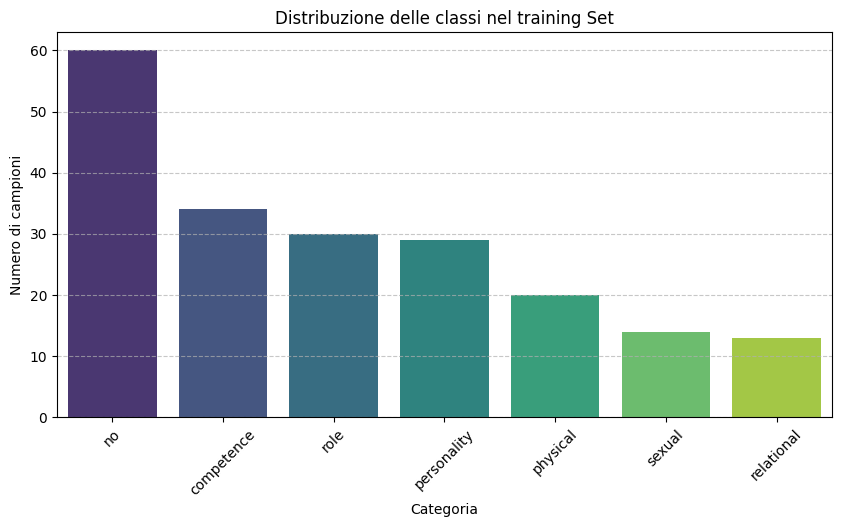

In [ ]:
conteggio = train_df['gs_category'].value_counts()

print("BILANCIAMENTO DELLE CLASSI")
print("\nValori assoluti:")
print(conteggio)

plt.figure(figsize=(10, 5))
sns.countplot(x='gs_category', data=train_df, order=conteggio.index, palette='viridis')
plt.title('Distribuzione delle classi nel training Set')
plt.xlabel('Categoria')
plt.ylabel('Numero di campioni')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Data Augmentation tramite Back-Translation

Considerata la scarsità e lo sbilanciamento dei dati emersi dall'analisi precedente, è stato deciso di applicare tecniche di Data Augmentation per arricchire il training set.
Nello specifico, è stato utilizzato il meccanismo di **Back-Translation**, che consiste nel tradurre gli esempi dalla lingua originale a una lingua "ponte", per poi ritradurli in quella di partenza. Questo processo introduce varianza lessicale e sintattica nei dati, preservandone il significato semantico originale.

Per l'implementazione ci siamo affidati ai seguenti modelli pre-addestrati di Helsinki-NLP:

- [`Helsinki-NLP/opus-mt-it-en`](https://huggingface.co/Helsinki-NLP/opus-mt-it-en) (per la traduzione da Italiano a Inglese)
- [`Helsinki-NLP/opus-mt-en-it`](https://huggingface.co/Helsinki-NLP/opus-mt-en-it) (per la ri-traduzione da Inglese a Italiano)

In [ ]:
aug = naw.BackTranslationAug(
    from_model_name='Helsinki-NLP/opus-mt-it-en',
    to_model_name='Helsinki-NLP/opus-mt-en-it',
    device=device,
    batch_size=8,
    max_length=300
)

print("Back Translation pronta!")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/344M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/344M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


...

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/789k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/814k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

Back Translation pronta!


## Motore di data augmentation sicura
Questa funzione gestisce l'arricchimento del dataset tramite Back-Translation, applicando tecniche avanzate per proteggere la struttura del testo. Nello specifico, il processo prevede:

- **Isolamento del contesto:** I metadati iniziali (es. il testo tra parentesi quadre) e le emoji finali vengono separati temporaneamente, affinché il traduttore si concentri solo sul corpo del messaggio.
- **Masking dei token:** I tag speciali come `[USER]` e `[URL]` vengono protetti per evitare che i modelli di traduzione li alterino o li eliminino.
- **Validazione dell'output:** Il sistema filtra e scarta automaticamente le frasi troppo corte, le traduzioni identiche all'originale e quelle in cui i tag protetti sono andati persi.

In [ ]:
def augmentation(df, num_aug=1):
    nuove_frasi = []

    if 'EMOJI_LIST' in globals() and len(EMOJI_LIST) > 0:
        emoji_chars = re.escape(''.join(EMOJI_LIST))
        emoji_pattern = r'(?:[' + emoji_chars + r']\s*)+$'
    else:
        emoji_pattern = r'$^'

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Traduzione Varianti"):
        original_text = row['text']
        nuove_frasi.append(row.to_dict())
        text_protected = original_text.replace('[USER]', 'User').replace('[URL]', 'Url')

        context_prefix = ""
        main_text = text_protected

        match_context = re.search(r'^(\[.*?\])\s*(.*)', text_protected, re.DOTALL)
        if match_context:
            context_prefix = match_context.group(1)
            main_text = match_context.group(2)

        emoji_suffix = ""
        text_to_augment = main_text
        match_emoji = re.search(emoji_pattern, main_text.strip())
        if match_emoji:
            emoji_suffix = match_emoji.group(0)
            text_to_augment = main_text.strip()[: -len(emoji_suffix)].strip()

        if len(text_to_augment.split()) >= 3:
            try:
                augmented_list = aug.augment(text_to_augment, n=max(num_aug, 3))

                if isinstance(augmented_list, str):
                  augmented_list = [augmented_list]

                augmented_list = list(set(augmented_list))

                count_added = 0
                for aug_text in augmented_list:
                    if count_added >= num_aug: break
                    final_text = f"{context_prefix} {aug_text} {emoji_suffix}".strip()

                    final_text = final_text.replace('User', '[USER]')
                    final_text = final_text.replace('Url', '[URL]')
                    final_text = re.sub(r'\s+', ' ', final_text).strip()

                    tag_ok = True
                    if '[USER]' in original_text and '[USER]' not in final_text: tag_ok = False
                    if '[URL]' in original_text and '[URL]' not in final_text: tag_ok = False

                    if final_text != original_text and tag_ok:
                        new_row = row.to_dict()
                        new_row['text'] = final_text

                        nuove_frasi.append(new_row)
                        count_added += 1

            except Exception as e:
                pass

    return pd.DataFrame(nuove_frasi)

Per mitigare lo sbilanciamento emerso durante l'esplorazione dei dati (EDA), la **Data Augmentation stratificata** è stata pesata applicando un moltiplicatore inversamente proporzionale alla frequenza della classe originale.

Questo approccio "su misura" assicura che il modello abbia abbastanza materiale per imparare i pattern delle minoranze, senza rischiare l'overfitting sulla categoria dominante.

In [ ]:
def get_aug_count(category):
    if category == 'no':
        return 0
    elif category in ['competence', 'role', 'personality']:
        return 1
    elif category == 'physical':
        return 2
    elif category in ['sexual', 'relational']:
        return 3
    return 1

print("Avvio data augmentation")

augmented_rows = []

for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Bilanciamento Dataset"):
    augmented_rows.append(row.to_dict())
    n_aug = get_aug_count(row['gs_category'])

    if n_aug > 0:
        single_row_df = pd.DataFrame([row])

        res_df = augmentation(single_row_df, num_aug=n_aug)

        original_text = row['text']
        new_variants = res_df[res_df['text'] != original_text].to_dict('records')

        augmented_rows.extend(new_variants)

train_aug_df = pd.DataFrame(augmented_rows)

print("-" * 50)
print(f"Dataset aumentato pronto")
print(f"Righe originali: {len(train_df)}")
print(f"Righe finali: {len(train_aug_df)}")
print("-" * 50)
print("Bilanciamento classi finale:")
print(train_aug_df['gs_category'].value_counts())

Avvio data augmentation


Bilanciamento Dataset: 100%|██████████| 200/200 [06:39<00:00,  2.00s/it]

--------------------------------------------------
Dataset aumentato pronto
Righe originali: 200
Righe finali: 337
--------------------------------------------------
Bilanciamento classi finale:
gs_category
competence     66
no             60
role           60
personality    58
physical       40
sexual         28
relational     25
Name: count, dtype: int64


In [ ]:
file_name = "/content/drive/MyDrive/GSIdetect/train_augmented.pkl"
train_aug_df.to_pickle(file_name)
print(f"Dataset salvato correttamente come '{file_name}'")

Dataset salvato correttamente come '/content/drive/MyDrive/GSIdetect/train_augmented.pkl'


## Arricchimento avanzato: Back-Translation (Italiano-Tedesco)

Nonostante il primo ciclo di Data Augmentation, le classi più minoritarie necessitavano di un ulteriore sovracampionamento per raggiungere un bilanciamento ottimale con la classe di maggioranza.

Per introdurre nuova varianza sintattica, è stato implementato un secondo step di Back-Translation utilizzando il tedesco come lingua ponte. Poiché il tedesco possiede una struttura grammaticale profondamente diversa dall'inglese, questo passaggio forza il modello a generare varianti testuali inedite e strutturalmente differenti rispetto al primo ciclo.

I modelli pre-addestrati utilizzati sono:

- [`Helsinki-NLP/opus-mt-it-de`](https://huggingface.co/Helsinki-NLP/opus-mt-it-de) (per la traduzione da Italiano a Tedesco)
- [`Helsinki-NLP/opus-mt-de-it`](https://huggingface.co/Helsinki-NLP/opus-mt-de-it) (per la ri-traduzione da Tedesco ad Italiano)

L'applicazione è stata mirata esclusivamente alle classi più deboli, introducendo un controllo rigoroso basato sui set logici per scartare eventuali duplicati e garantire che il dataset finale contenga solo frasi uniche.

In [ ]:
aug_de = naw.BackTranslationAug(
    from_model_name='Helsinki-NLP/opus-mt-it-de',
    to_model_name='Helsinki-NLP/opus-mt-de-it',
    device=device,
    batch_size=8,
    max_length=300
)

print("Back Translation pronta!")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/302M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/302M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


...

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/829k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/814k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

Back Translation pronta!


In [ ]:
if 'aug' in globals():
    aug_inglese_backup = aug
aug = aug_de

classi_deboli = ['sexual', 'relational', 'physical']

df_da_rinforzare = train_df[train_df['gs_category'].isin(classi_deboli)]
print(f"Trovate {len(df_da_rinforzare)} frasi originali da rinforzare col Tedesco.")

nuove_righe_tedesco = []
frasi_esistenti = set(train_aug_df['text'].values)

for _, row in tqdm(df_da_rinforzare.iterrows(), total=len(df_da_rinforzare), desc="Generazione Tedesca"):
    try:
        df_singolo = pd.DataFrame([row])
        res_df = augmentation(df_singolo, num_aug=3)

        original_text = row['text']
        candidati = res_df[res_df['text'] != original_text].to_dict('records')

        for cand in candidati:
            if cand['text'] not in frasi_esistenti:
                nuove_righe_tedesco.append(cand)
                frasi_esistenti.add(cand['text'])

    except Exception as e:
        pass

if 'aug_inglese_backup' in globals():
    aug = aug_inglese_backup

if len(nuove_righe_tedesco) > 0:
    df_extra = pd.DataFrame(nuove_righe_tedesco)
    train_final_df = pd.concat([train_aug_df, df_extra], ignore_index=True)
    print(f" Aggiunte {len(df_extra)} nuove varianti uniche dal Tedesco!")
else:
    train_final_df = train_aug_df
    print(" Il tedesco non ha prodotto varianti nuove rispetto all'inglese.")

print("-" * 50)
print(" BILANCIAMENTO FINALE DEFINITIVO:")
print(train_final_df['gs_category'].value_counts())

Trovate 47 frasi originali da rinforzare col Tedesco.


Generazione Tedesca: 100%|██████████| 47/47 [02:26<00:00,  3.12s/it]

 Aggiunte 45 nuove varianti uniche dal Tedesco!
--------------------------------------------------
 BILANCIAMENTO FINALE DEFINITIVO:
gs_category
competence     66
no             60
role           60
personality    58
physical       58
sexual         42
relational     38
Name: count, dtype: int64


In [ ]:
train_final_df.to_pickle("/content/drive/MyDrive/GSIdetect/train_dataset_completo.pkl")
print(" Dataset COMPLETO (Inglese + Tedesco) salvato")

 Dataset COMPLETO (Inglese + Tedesco) salvato


In [ ]:
train_df = pd.read_pickle(f"/content/drive/MyDrive/GSIdetect/train_dataset_completo.pkl")

## Validazione finale del bilanciamento

Dopo aver completato i due cicli di Data Augmentation (Inglese e Tedesco), è stata effettuata una verifica statistica e visuale della distribuzione finale delle classi.

Questa analisi serve a confermare che il divario tra la classe di maggioranza e le classi minoritarie sia stato ridotto drasticamente. Un dataset così bilanciato permetterà a BERT di apprendere i pattern degli insulti specifici (physical, sexual, ecc.) con la stessa efficacia con cui riconosce i casi non offensivi, evitando che il modello sia polarizzato verso la classe più frequente.

BILANCIAMENTO DELLE CLASSI

Valori assoluti:
gs_category
competence     66
no             60
role           60
personality    58
physical       58
sexual         42
relational     38
Name: count, dtype: int64


/tmp/ipython-input-968550979.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gs_category', data=train_df, order=conteggio.index, palette='viridis')


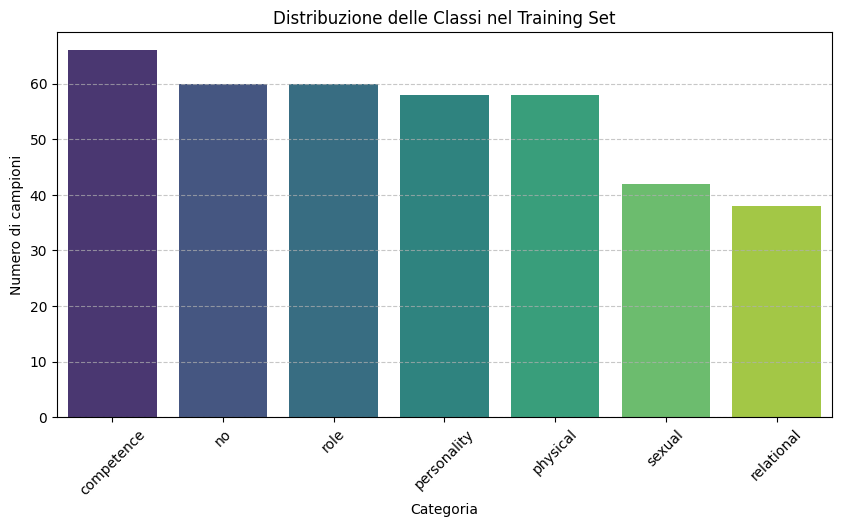

In [ ]:
conteggio = train_df['gs_category'].value_counts()

print("BILANCIAMENTO DELLE CLASSI")
print("\nValori assoluti:")
print(conteggio)


plt.figure(figsize=(10, 5))
sns.countplot(x='gs_category', data=train_df, order=conteggio.index, palette='viridis')
plt.title('Distribuzione delle Classi nel Training Set')
plt.xlabel('Categoria')
plt.ylabel('Numero di campioni')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Dall'analisi del grafico finale, si osserva che le classi `sexual` e `relational` mantengono un numero di campioni inferiore rispetto alle altre categorie, nonostante il duplice ciclo di augmentation.

Il fenomeno è dovuto alla natura dei campioni originali in queste categorie, caratterizzati da frasi estremamente brevi e sintatticamente semplici. In questi casi, i modelli di Back-Translation tendono a produrre output identici all'originale, poiché la varianza lessicale possibile è minima.

È stato quindi deciso di non procedere con ulteriori lingue ponte, in quanto il guadagno in termini di nuovi campioni unici sarebbe stato trascurabile rispetto al rumore introdotto. Il dataset ottenuto rappresenta comunque il miglior compromesso possibile tra numerosità e qualità semantica dei dati.

# Espansione del Vocabolario

Poiché il modello pre-addestrato originale non include nel suo vocabolario i simboli grafici e le emoji presenti nel nostro dataset, è stato necessario procedere con un'operazione di **Vocabulary Expansion**:

1. **Identificazione:** Sono stati estratti tutti i caratteri unici dal dataset che venivano mappati dal tokenizer come `[UNK]` (Unknown).
2. **Aggiornamento tokenizer:** Questi simboli sono stati aggiunti formalmente al tokenizer come nuovi token atomici.
3. **Ridimensionamento:** L'aggiornamento del vocabolario è un passaggio critico che richiederà il ridimensionamento dello strato di *Embedding* della rete neurale per riflettere la nuova dimensione (`NEW_VOCAB_SIZE`).

Questo garantisce che le emoji vengano elaborate come entità dotate di significato proprio, migliorando la capacità del modello di catturare sfumature semantiche e toni ironici o aggressivi.

In [ ]:
# MODEL_NAME = "dbmdz/bert-base-italian-xxl-cased"
# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Vocabolario originale: {len(tokenizer)} token")

testo_train = train_df['text'].tolist()
testo_test = test_df['text'].tolist()
testo_completo = " ".join(testo_train + testo_test)

caratteri_unici = set(testo_completo)

tokens_da_aggiungere = []
for char in caratteri_unici:
    if tokenizer.encode(char, add_special_tokens=False) == [tokenizer.unk_token_id]:
        tokens_da_aggiungere.append(char)

print(f"Trovati {len(tokens_da_aggiungere)} nuovi simboli da insegnare a BERT.")

if len(tokens_da_aggiungere) > 0:
    print(f"Esempi: {tokens_da_aggiungere[:10]}")

    num_added_tokens = tokenizer.add_tokens(tokens_da_aggiungere)
    print(f"Aggiunti {num_added_tokens} token.")
else:
    print("Nessun nuovo token trovato.")

print(f"Nuova dimensione Vocabolario: {len(tokenizer)} token")

NEW_VOCAB_SIZE = len(tokenizer)
EMOJI_LIST = tokens_da_aggiungere

Vocabolario originale: 31102 token
Trovati 95 nuovi simboli da insegnare a BERT.
Esempi: ['🛋', '👏', '🤧', '🔥', '😉', '🟢', '🤭', '💸', '😘', '🥱']
Aggiunti 95 token.
Nuova dimensione Vocabolario: 31197 token


## Inizializzazione e salvataggio del modello custom

Per rendere effettive le modifiche al vocabolario e permettere al modello di processare i nuovi token, è stata definita un'architettura personalizzata `BERTResize`.

In questo modo non ci sarà bisogno rieseguire la procedura di "insegnamento" dei nuovi caratteri ad ogni sessione: basterà caricare questo checkpoint per avere un modello già pronto a comprendere l'intero set di caratteri del dataset.

In [ ]:
class BERTResize(nn.Module):
    def __init__(self, new_vocab_size):
        super(BERTResize, self).__init__()

        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        self.bert.resize_token_embeddings(new_vocab_size)
        self.drop = nn.Dropout(p=0.3)
        self.out = nn.Linear(768, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_ids, attention_mask):
        output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        output = self.drop(output.pooler_output)

        return self.sigmoid(self.out(output))

In [ ]:
SAVE_PATH = '/content/drive/MyDrive/GSIdetect/bert_resize/'
os.makedirs(SAVE_PATH, exist_ok=True)

model = BERTResize(new_vocab_size=len(tokenizer))

model.to(device)

tokenizer.save_pretrained(SAVE_PATH)
torch.save(model.state_dict(), os.path.join(SAVE_PATH, 'weights.pth'))

print(f"Modello salvato in: {SAVE_PATH}")

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dbmdz/bert-base-italian-xxl-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modello salvato in: /content/drive/MyDrive/GSIdetect/bert_resize/
